# Smart PDF Figure Screenshot Extractor

This notebook takes **screenshots of FIGURE regions** from PDFs, preserving:
- ✅ The actual diagram/image
- ✅ All text labels and annotations within the figure
- ✅ The complete figure caption below
- ✅ Figure numbers (FIGURE 1-1, FIGURE 2-1, etc.)

**This approach captures the entire figure as it appears in the book, not just the embedded image!**

Perfect for medical textbooks, anatomy diagrams, and any figures with important text annotations!

## Step 1: Install Required Libraries

In [1]:
# Install required packages
!pip install -q pymupdf PyMuPDF Pillow

print("✅ All packages installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.1/24.1 MB 39.1 MB/s eta 0:00:00
✅ All packages installed successfully!


## Step 2: Import Libraries

In [2]:
import fitz  # PyMuPDF
import os
from pathlib import Path
from PIL import Image
import json
from datetime import datetime
import re

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## Step 4: Upload PDF File from Your Computer

In [3]:
# Upload PDF from your computer
from google.colab import files
uploaded = files.upload()
pdf_path = list(uploaded.keys())[0]

print(f"✅ PDF file uploaded: {pdf_path}")

Saving skin-care-beyond-the-basics-4th.pdf to skin-care-beyond-the-basics-4th.pdf
✅ PDF file uploaded: skin-care-beyond-the-basics-4th.pdf


## Step 5: Figure Screenshot Extractor Class

In [4]:
class FigureScreenshotExtractor:
    """
    Extracts figure screenshots from PDFs by rendering full-width horizontal regions.
    Captures from top of figure to bottom of caption across the entire page width.
    """

    def __init__(self, pdf_path, output_dir="output", dpi=300, padding=20):
        """
        Initialize the figure screenshot extractor.

        Args:
            pdf_path (str): Path to the PDF file
            output_dir (str): Directory to save output files
            dpi (int): Resolution for page rendering (default: 300 for high quality)
            padding (int): Extra pixels to include around figure area vertically (default: 20)
        """
        self.pdf_path = pdf_path
        self.output_dir = output_dir
        self.images_dir = os.path.join(output_dir, "images")
        self.dpi = dpi
        self.padding = padding

        # Create output directories
        os.makedirs(self.output_dir, exist_ok=True)
        os.makedirs(self.images_dir, exist_ok=True)

        # Open PDF
        self.doc = fitz.open(pdf_path)
        self.figure_counter = 0
        self.skipped_counter = 0

    def clean_text(self, text):
        """Clean and normalize extracted text."""
        text = re.sub(r'\s+', ' ', text)
        return text.strip()

    def find_figure_regions(self, page):
        """
        Find all figure regions on a page by looking for FIGURE captions,
        then finding content above the caption. Returns full-width horizontal bounding boxes.

        Args:
            page: PyMuPDF page object

        Returns:
            list: List of dictionaries with figure info and bounding boxes
        """
        blocks = page.get_text("dict")["blocks"]
        figure_regions = []
        page_width = page.rect.width
        page_height = page.rect.height

        # Get all images on the page with their positions
        image_list = page.get_images(full=True)
        image_bboxes = []
        for img in image_list:
            xref = img[0]
            try:
                img_rects = page.get_image_rects(xref)
                if img_rects:
                    image_bboxes.extend(img_rects)
            except:
                pass

        # Find all FIGURE captions
        for block in blocks:
            if block["type"] == 0:  # Text block
                # Extract text from block
                text = ""
                for line in block.get("lines", []):
                    for span in line.get("spans", []):
                        text += span.get("text", "") + " "

                text = self.clean_text(text)

                # Look for FIGURE pattern
                figure_patterns = [
                    r'FIGURE\s+([\d]+[-\.][\d]+[A-Z]?)',  # FIGURE 1-1, FIGURE 2.3
                    r'FIGURE\s+([\d]+)',                   # FIGURE 1
                    r'Fig\.?\s+([\d]+[-\.][\d]+[A-Z]?)',  # Fig. 1-1
                    r'Fig\.?\s+([\d]+)'                    # Fig 1
                ]

                figure_match = None
                for pattern in figure_patterns:
                    match = re.search(pattern, text, re.IGNORECASE)
                    if match:
                        figure_match = match
                        break

                if figure_match:
                    figure_num = figure_match.group(1)
                    caption_bbox = block["bbox"]

                    # Extend caption area to include multi-line captions
                    caption_start_y = caption_bbox[1]
                    caption_end_y = caption_bbox[3]
                    full_caption_text = text

                    # Look for continuation of caption below
                    for next_block in blocks:
                        if next_block["type"] == 0:
                            next_bbox = next_block["bbox"]
                            # Check if this block is part of the same caption
                            if (next_bbox[1] >= caption_end_y and
                                next_bbox[1] - caption_end_y < 20 and
                                abs(next_bbox[0] - caption_bbox[0]) < 50):
                                caption_end_y = next_bbox[3]
                                # Add text to caption
                                next_text = ""
                                for line in next_block.get("lines", []):
                                    for span in line.get("spans", []):
                                        next_text += span.get("text", "") + " "
                                full_caption_text += " " + next_text

                    # Find all images that are ABOVE this caption
                    related_images = []
                    for img_bbox in image_bboxes:
                        # Check if image is above the caption (with some margin)
                        if img_bbox[3] < caption_start_y - 10:  # Image bottom is above caption
                            related_images.append(img_bbox)

                    # Determine figure boundaries - FULL WIDTH HORIZONTAL
                    if related_images:
                        # Find the topmost and bottommost points of images
                        min_y = min([img[1] for img in related_images])
                        max_y = max([img[3] for img in related_images])

                        # Create FULL-WIDTH horizontal screenshot
                        # From left edge to right edge of page
                        x0 = 0
                        y0 = max(0, min_y - self.padding * 2)
                        x1 = page_width
                        y1 = min(page_height, caption_end_y + self.padding)
                    else:
                        # No images found, use a default search area above caption
                        # FULL-WIDTH horizontal region
                        x0 = 0
                        y0 = max(0, caption_bbox[1] - 450)  # Search ~450 points above
                        x1 = page_width
                        y1 = min(page_height, caption_end_y + self.padding)

                    figure_regions.append({
                        'figure_num': figure_num,
                        'caption': self.clean_text(full_caption_text),
                        'bbox': (x0, y0, x1, y1),
                        'caption_bbox': caption_bbox,
                        'num_images': len(related_images)
                    })

        return figure_regions

    def screenshot_figure_region(self, page, bbox, figure_num, page_num):
        """
        Take a full-width horizontal screenshot of a specific region of the page.

        Args:
            page: PyMuPDF page object
            bbox: Bounding box (x0, y0, x1, y1)
            figure_num: Figure number for filename
            page_num: Page number

        Returns:
            str: Path to saved image
        """
        # Create a rectangle for the region
        rect = fitz.Rect(bbox)

        # Calculate zoom factor based on DPI
        # 72 DPI is the default, so zoom = target_dpi / 72
        zoom = self.dpi / 72
        mat = fitz.Matrix(zoom, zoom)

        # Render the page
        pix = page.get_pixmap(matrix=mat, clip=rect)

        # Generate filename
        safe_fig_num = figure_num.replace('-', '_').replace('.', '_').replace(' ', '_')
        image_filename = f"figure_{safe_fig_num}.png"
        image_path = os.path.join(self.images_dir, image_filename)

        # Save as PNG
        pix.save(image_path)

        return image_filename

    def extract_figures_from_page(self, page, page_num):
        """
        Extract all figure screenshots from a PDF page.

        Args:
            page: PyMuPDF page object
            page_num (int): Page number

        Returns:
            list: List of dictionaries with figure info
        """
        figure_regions = self.find_figure_regions(page)
        extracted_figures = []

        if not figure_regions:
            print(f"  ℹ️  No FIGURE captions found on page {page_num}")
            return extracted_figures

        print(f"  📍 Found {len(figure_regions)} figure(s) on page {page_num}")

        for region in figure_regions:
            try:
                # Take screenshot of the figure region
                image_filename = self.screenshot_figure_region(
                    page,
                    region['bbox'],
                    region['figure_num'],
                    page_num
                )

                self.figure_counter += 1

                extracted_figures.append({
                    'filename': image_filename,
                    'figure_num': region['figure_num'],
                    'caption': region['caption'],
                    'page': page_num,
                    'bbox': region['bbox'],
                    'num_images': region.get('num_images', 0)
                })

                print(f"  ✅ Captured FIGURE {region['figure_num']}: {image_filename}")
                print(f"     Full-width horizontal screenshot")
                print(f"     Height: {int(region['bbox'][3] - region['bbox'][1])} pixels")
                # Truncate caption for display
                caption_preview = region['caption'][:100] + "..." if len(region['caption']) > 100 else region['caption']
                print(f"     Caption: {caption_preview}")

            except Exception as e:
                print(f"  ⚠️ Error capturing figure {region['figure_num']} on page {page_num}: {e}")
                self.skipped_counter += 1

        return extracted_figures

    def extract_text_from_page(self, page):
        """
        Extract text from a page with structure detection.
        """
        blocks = page.get_text("dict")["blocks"]
        markdown_text = ""

        for block in blocks:
            if block["type"] == 0:  # Text block
                text = ""
                font_size = 0

                for line in block.get("lines", []):
                    for span in line.get("spans", []):
                        text += span.get("text", "")
                        if span.get("size", 0) > font_size:
                            font_size = span.get("size", 0)
                    text += " "

                text = self.clean_text(text)

                if text:
                    # Detect if it's a heading based on font size
                    if font_size > 18:
                        markdown_text += f"\n# {text}\n\n"
                    elif font_size > 14:
                        markdown_text += f"\n## {text}\n\n"
                    elif font_size > 12:
                        markdown_text += f"\n### {text}\n\n"
                    else:
                        markdown_text += f"{text}\n\n"

        return markdown_text

    def convert_to_markdown(self):
        """
        Convert entire PDF to Markdown with figure screenshots.

        Returns:
            str: Path to the generated markdown file
        """
        print(f"\n🚀 Starting full-width figure screenshot extraction from: {self.pdf_path}")
        print(f"📄 Total pages: {len(self.doc)}")
        print(f"🖼️  Resolution: {self.dpi} DPI")
        print(f"📏 Screenshot width: Full page width")
        print(f"📏 Vertical padding: {self.padding} pixels\n")

        markdown_content = f"# {Path(self.pdf_path).stem}\n\n"
        markdown_content += f"*Extracted on: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}*\n\n"
        markdown_content += "*Note: Figures are full-width horizontal screenshots from top to bottom including captions*\n\n"
        markdown_content += "---\n\n"

        all_figures = []

        # Process each page
        for page_num in range(len(self.doc)):
            print(f"\n📖 Processing page {page_num + 1}/{len(self.doc)}...")

            page = self.doc[page_num]

            # Add page marker
            markdown_content += f"\n## Page {page_num + 1}\n\n"

            # Extract text
            text = self.extract_text_from_page(page)
            markdown_content += text

            # Extract figure screenshots
            figures = self.extract_figures_from_page(page, page_num + 1)
            all_figures.extend(figures)

            # Add figure references to markdown
            if figures:
                markdown_content += "\n### 📊 Figures on This Page\n\n"
                for fig in figures:
                    markdown_content += f"#### FIGURE {fig['figure_num']}\n\n"
                    markdown_content += f"![Figure {fig['figure_num']}](images/{fig['filename']})\n\n"
                    markdown_content += f"**Caption:** *{fig['caption']}*\n\n"
                    markdown_content += "---\n\n"

        # Add figure index at the end
        if all_figures:
            markdown_content += "\n\n# 📑 Figure Index\n\n"
            markdown_content += "| Figure | Caption | Page |\n"
            markdown_content += "|--------|---------|------|\n"
            for fig in all_figures:
                caption_short = fig['caption'][:60] + "..." if len(fig['caption']) > 60 else fig['caption']
                markdown_content += f"| FIGURE {fig['figure_num']} | {caption_short} | {fig['page']} |\n"

        # Save markdown file
        output_filename = Path(self.pdf_path).stem + "_figures.md"
        output_path = os.path.join(self.output_dir, output_filename)

        with open(output_path, "w", encoding="utf-8") as f:
            f.write(markdown_content)

        print(f"\n" + "="*60)
        print("✅ EXTRACTION COMPLETE!")
        print("="*60)
        print(f"📝 Markdown file: {output_path}")
        print(f"✅ Figures captured: {self.figure_counter}")
        print(f"⚠️  Errors: {self.skipped_counter}")
        print(f"📁 Images directory: {self.images_dir}")
        print(f"🖼️  Resolution: {self.dpi} DPI (full-width horizontal screenshots)")

        return output_path

    def generate_summary(self):
        """
        Generate a summary JSON file with extraction statistics.
        """
        summary = {
            "pdf_file": self.pdf_path,
            "total_pages": len(self.doc),
            "figures_captured": self.figure_counter,
            "errors": self.skipped_counter,
            "resolution_dpi": self.dpi,
            "padding_pixels": self.padding,
            "output_directory": self.output_dir,
            "extraction_date": datetime.now().isoformat(),
            "method": "full_width_horizontal_screenshot"
        }

        summary_path = os.path.join(self.output_dir, "extraction_summary.json")
        with open(summary_path, "w", encoding="utf-8") as f:
            json.dump(summary, f, indent=2)

        return summary

    def close(self):
        """Close the PDF document."""
        self.doc.close()

print("✅ FigureScreenshotExtractor class defined!")
print("   📏 Configured for full-width horizontal screenshots")
print("   🎯 Captures from top of figure to bottom of caption")

✅ FigureScreenshotExtractor class defined!
   📏 Configured for full-width horizontal screenshots
   🎯 Captures from top of figure to bottom of caption


## Step 6: Configure Extraction Settings

Adjust these settings to control screenshot quality and region detection:

In [5]:
# ===== EXTRACTION SETTINGS =====

# Output directory
output_directory = "figure_screenshots"

# Resolution for screenshots (DPI)
# Higher = better quality but larger files
#   - 150 DPI = Good for web/screen viewing
#   - 300 DPI = High quality, recommended for printing
#   - 600 DPI = Very high quality (large files)
DPI = 300

# Vertical padding around figure region (in pixels)
# Extra space to include above and below the figure
PADDING = 30

print("✅ Extraction settings configured!")
print(f"   📁 Output: {output_directory}")
print(f"   🖼️  Resolution: {DPI} DPI")
print(f"   📏 Vertical Padding: {PADDING} pixels")
print(f"   📐 Screenshot Style: Full-width horizontal")
print(f"   🎯 Captures entire page width from top of figure to bottom of caption")

✅ Extraction settings configured!
   📁 Output: figure_screenshots
   🖼️  Resolution: 300 DPI
   📏 Vertical Padding: 30 pixels
   📐 Screenshot Style: Full-width horizontal
   🎯 Captures entire page width from top of figure to bottom of caption


## Step 7: Run the Screenshot Extraction

In [6]:
# Create extractor instance
extractor = FigureScreenshotExtractor(
    pdf_path,
    output_dir=output_directory,
    dpi=DPI,
    padding=PADDING
)

# Convert PDF to Markdown with figure screenshots
markdown_file = extractor.convert_to_markdown()

# Generate summary
summary = extractor.generate_summary()

# Close the PDF
extractor.close()

print("\n" + "="*60)
print("📊 DETAILED SUMMARY")
print("="*60)
for key, value in summary.items():
    print(f"  {key}: {value}")


🚀 Starting full-width figure screenshot extraction from: skin-care-beyond-the-basics-4th.pdf
📄 Total pages: 528
🖼️  Resolution: 300 DPI
📏 Screenshot width: Full page width
📏 Vertical padding: 30 pixels


📖 Processing page 1/528...
  ℹ️  No FIGURE captions found on page 1

📖 Processing page 2/528...
  ℹ️  No FIGURE captions found on page 2

📖 Processing page 3/528...
  ℹ️  No FIGURE captions found on page 3

📖 Processing page 4/528...
  ℹ️  No FIGURE captions found on page 4

📖 Processing page 5/528...
  ℹ️  No FIGURE captions found on page 5

📖 Processing page 6/528...
  ℹ️  No FIGURE captions found on page 6

📖 Processing page 7/528...
  ℹ️  No FIGURE captions found on page 7

📖 Processing page 8/528...
  ℹ️  No FIGURE captions found on page 8

📖 Processing page 9/528...
  ℹ️  No FIGURE captions found on page 9

📖 Processing page 10/528...
  ℹ️  No FIGURE captions found on page 10

📖 Processing page 11/528...
  ℹ️  No FIGURE captions found on page 11

📖 Processing page 12/528...
  ℹ️

## Step 8: Preview Extracted Figure Screenshots

📷 Found 240 extracted figure screenshots

  1. figure_10_1.png - Size: 2575x1965 pixels
  2. figure_11_1.png - Size: 2575x1520 pixels
  3. figure_11_2.png - Size: 2575x1469 pixels
  4. figure_11_3.png - Size: 2575x1365 pixels
  5. figure_11_3A.png - Size: 2575x3048 pixels
  6. figure_11_3B.png - Size: 2575x3098 pixels
  7. figure_11_4.png - Size: 2575x1801 pixels
  8. figure_11_5.png - Size: 2575x2270 pixels
  9. figure_12_1.png - Size: 2575x1644 pixels
  10. figure_13_1.png - Size: 2575x3046 pixels
  11. figure_13_1A.png - Size: 2575x1391 pixels
  12. figure_13_1B.png - Size: 2575x1341 pixels
  13. figure_13_2.png - Size: 2575x2700 pixels
  14. figure_13_3.png - Size: 2575x2683 pixels
  15. figure_13_4.png - Size: 2575x2265 pixels
  16. figure_13_5.png - Size: 2575x1427 pixels
  17. figure_13_6.png - Size: 2575x1182 pixels
  18. figure_13_7.png - Size: 2575x2681 pixels
  19. figure_13_8.png - Size: 2575x3053 pixels
  20. figure_14_1.png - Size: 2575x1861 pixels
  21. figure_14_10.png 

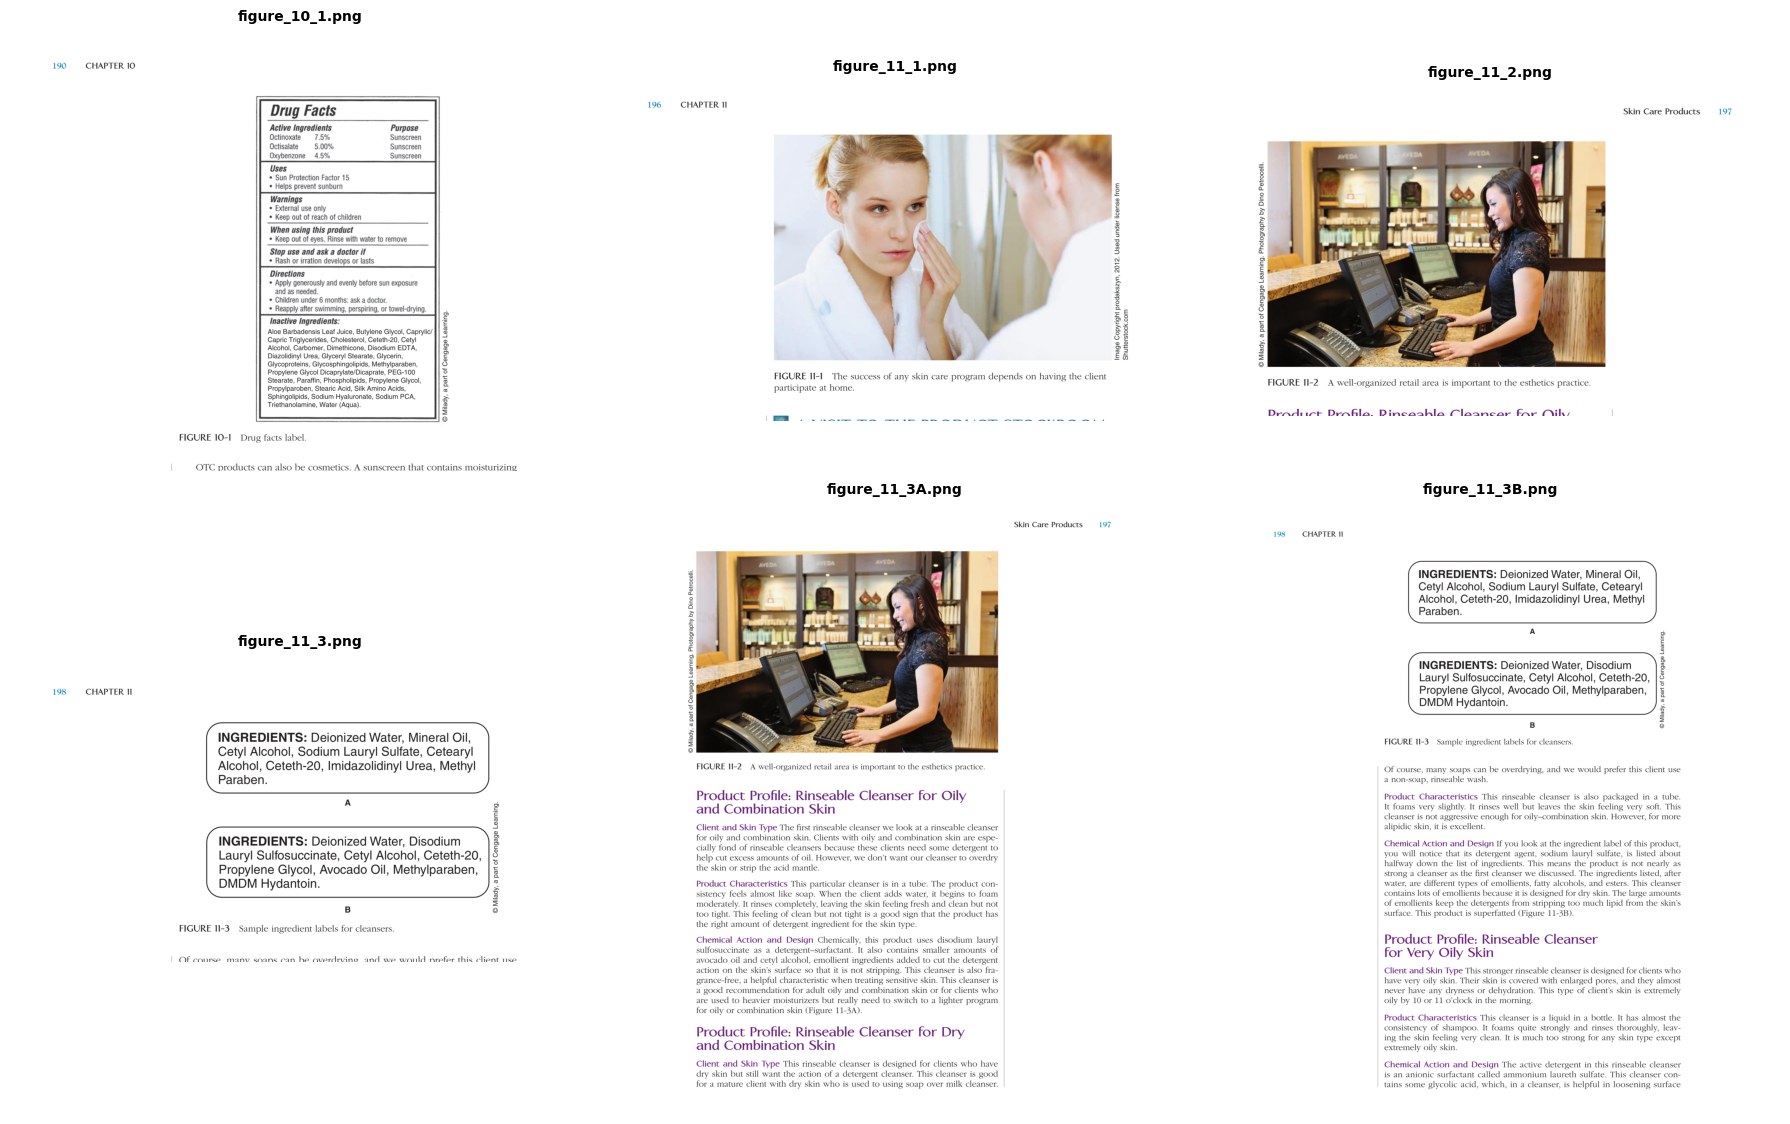


✅ Displayed 6 of 240 figure screenshots

💡 These screenshots include the complete figure with all text labels and annotations!


In [7]:
import matplotlib.pyplot as plt
from PIL import Image
import glob

# Get all extracted figures
figure_files = sorted(glob.glob(os.path.join(output_directory, "images", "figure_*.png")))

if figure_files:
    print(f"📷 Found {len(figure_files)} extracted figure screenshots\n")

    # List all figures
    for i, fig_path in enumerate(figure_files, 1):
        img = Image.open(fig_path)
        print(f"  {i}. {os.path.basename(fig_path)} - Size: {img.size[0]}x{img.size[1]} pixels")

    # Display first 6 figures
    num_to_display = min(6, len(figure_files))
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()

    for idx, img_path in enumerate(figure_files[:num_to_display]):
        img = Image.open(img_path)
        axes[idx].imshow(img)
        axes[idx].set_title(os.path.basename(img_path), fontsize=10, fontweight='bold')
        axes[idx].axis('off')

    # Hide unused subplots
    for idx in range(num_to_display, 6):
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()

    print(f"\n✅ Displayed {num_to_display} of {len(figure_files)} figure screenshots")
    print(f"\n💡 These screenshots include the complete figure with all text labels and annotations!")
else:
    print("⚠️ No figures were extracted. Try adjusting SEARCH_DISTANCE.")

## Step 9: Compare Screenshot vs Embedded Image

Let's see the difference in quality and content!

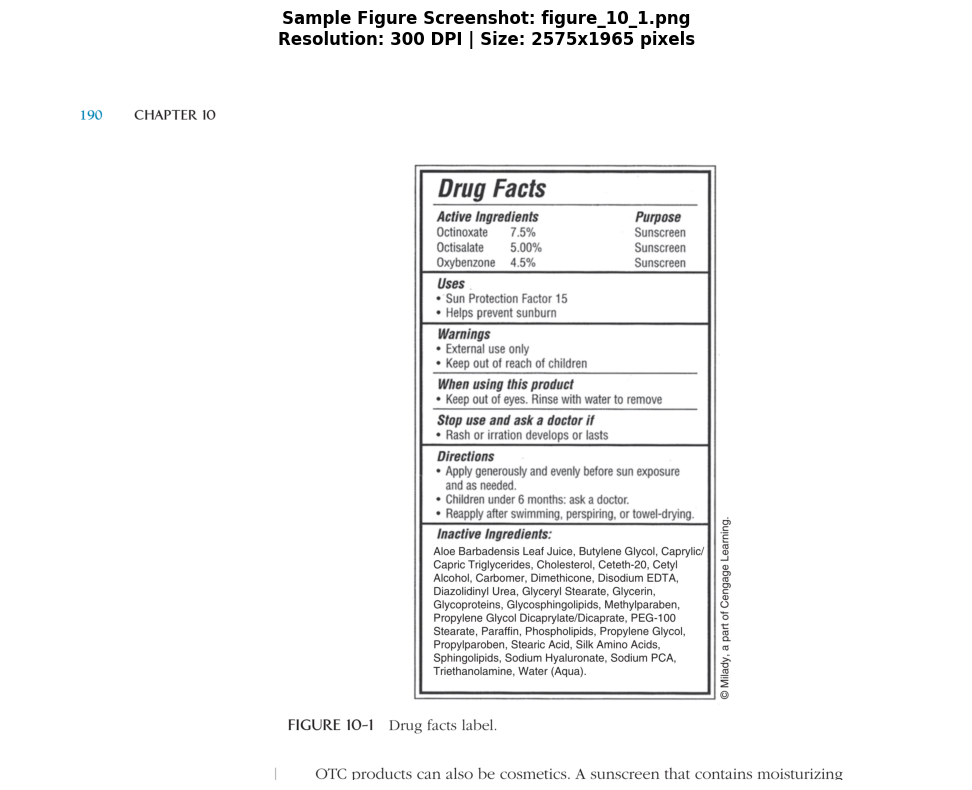


✅ This screenshot includes:
   • The complete diagram/image
   • All text labels and annotations within the figure
   • The figure caption below
   • Proper spacing and layout as it appears in the book

📝 Perfect for studying medical diagrams, anatomy, or any annotated figures!


In [8]:
if figure_files:
    # Show first figure in detail
    first_figure = Image.open(figure_files[0])

    plt.figure(figsize=(12, 8))
    plt.imshow(first_figure)
    plt.title(f"Sample Figure Screenshot: {os.path.basename(figure_files[0])}\n"
              f"Resolution: {DPI} DPI | Size: {first_figure.size[0]}x{first_figure.size[1]} pixels",
              fontsize=12, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    print("\n✅ This screenshot includes:")
    print("   • The complete diagram/image")
    print("   • All text labels and annotations within the figure")
    print("   • The figure caption below")
    print("   • Proper spacing and layout as it appears in the book")
    print("\n📝 Perfect for studying medical diagrams, anatomy, or any annotated figures!")

## Step 10: Preview the Markdown File

In [9]:
# Read and display portion of the markdown file
with open(markdown_file, "r", encoding="utf-8") as f:
    content = f.read()

print("📝 MARKDOWN PREVIEW:")
print("="*70)
print(content[:3000])  # Show first 3000 characters
print("\n...\n")
print(f"(Full document: {len(content)} characters, {content.count('FIGURE')} figure references)")

📝 MARKDOWN PREVIEW:
# skin-care-beyond-the-basics-4th

*Extracted on: 2025-10-22 06:33:02*

*Note: Figures are full-width horizontal screenshots from top to bottom including captions*

---


## Page 1


## Page 2


# Skin Care Beyond the Basics


## Fourth Edition


# Mark Lees

Australia • Brazil • Japan • Korea • Mexico • Singapore • Spain • United Kingdom • United States

Copyright 2012 Cengage Learning. All Rights Reserved. May not be copied, scanned, or duplicated, in whole or in part. Due to electronic rights, some third party content may be suppressed from the eBook and/or eChapter(s). Editorial review has deemed that any suppressed content does not materially affect the overall learning experience. Cengage Learning reserves the right to remove additional content at any time if subsequent rights restrictions require it.


## Page 3

This is an electronic version of the print textbook. Due to electronic rights restrictions, some third party content may be suppressed. Editorial re

## Step 11: Download Results

Download the markdown file and figure screenshots as a zip file.

In [10]:
import shutil

# Create a zip file with all results
zip_filename = "figure_screenshots"
shutil.make_archive(zip_filename, 'zip', output_directory)

file_size_mb = os.path.getsize(f"{zip_filename}.zip") / (1024 * 1024)

print(f"📦 Created: {zip_filename}.zip")
print(f"   Size: {file_size_mb:.2f} MB")
print(f"   Contains: Markdown file + {summary['figures_captured']} figure screenshots at {DPI} DPI")

# Download the zip file
from google.colab import files
files.download(f"{zip_filename}.zip")

print("\n✅ Download started! Check your browser's download folder.")

📦 Created: figure_screenshots.zip
   Size: 346.69 MB
   Contains: Markdown file + 390 figure screenshots at 300 DPI


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Download started! Check your browser's download folder.


## 🎯 Why Screenshots Are Better

### **Traditional Image Extraction:**
- ❌ Only gets the embedded image file
- ❌ Loses text labels overlaid on the image
- ❌ Misses annotations and callouts
- ❌ Caption not included with image

### **Screenshot Method (This Notebook):**
- ✅ Captures the entire figure as rendered
- ✅ Includes all text labels and annotations
- ✅ Preserves layout and spacing
- ✅ Includes caption in the same screenshot
- ✅ High resolution (configurable DPI)
- ✅ Perfect for medical textbooks, anatomy diagrams, etc.

### **Perfect For:**
- 📚 Medical and anatomy textbooks
- 🧬 Biology diagrams with labels
- 🔬 Scientific figures with annotations
- 📊 Charts and graphs with text
- 🎨 Any figures where text is part of the image

## 🔧 Troubleshooting Tips

### If figures are cut off or incomplete:
- Increase `PADDING` (default: 30) for more margin around detected figure area
- The system automatically detects all images above FIGURE captions
- Check the output - it shows how many images were found for each figure

### If too much content is captured:
- Decrease `PADDING` for tighter cropping around the figure
- The system uses image positions to determine boundaries

### If no figures are found:
- Check if the PDF uses "FIGURE", "Fig.", or "Fig" in captions
- Verify the PDF is text-based (not scanned images requiring OCR)
- Look at the console output to see what's being detected

### For better quality:
- Increase `DPI` (300 is good, 600 is excellent but creates larger files)
- Higher DPI = sharper text and diagrams

### For smaller file sizes:
- Decrease `DPI` (150 is acceptable for screen viewing)
- Lower DPI = smaller files but less crisp text

### Understanding the detection:
- The system finds FIGURE captions first
- Then locates all images positioned above that caption
- Calculates a bounding box that includes all images + caption
- Takes a high-resolution screenshot of that region